<a href="https://colab.research.google.com/github/ismethakanaydogmus/News_Classification/blob/main/news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 Haber Başlıkları ile Çok Sınıflı Sınıflandırma Analizi
# Multi-Class News Classification Analysis via Headlines

## 📌 Proje Özeti / Project Overview
Bu proje, Türkiye'nin önde gelen haber kaynaklarından (BBC Türkçe, Hürriyet, Habertürk) kazınan verilerle 7 farklı kategoride (Ekonomi, Sağlık, Bilim, Teknoloji, Eğitim, Astroloji, Spor) haber sınıflandırması yapmayı amaçlamaktadır.

This project aims to classify news into 7 distinct categories using data scraped from major Turkish news outlets.

### 🛠 Kullanılan Teknolojiler / Technologies Used
* **Veri Kazıma:** VS Code, Selenium, BeautifulSoup
* **Analiz & Modelleme:** Google Colab, Pandas, Scikit-learn
* **Görselleştirme:** Matplotlib, Seaborn
* **NLP:** NLTK, Regex

In [37]:
# Projeyi GitHub'dan çekme / Cloning the project
!git clone https://github.com/ismethakanaydogmus/News_Classification.git
%cd News_Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords

# Görselleştirme ayarları
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Veriyi yükle
df = pd.read_csv("master_news_dataset.csv")
print(f"Veri Seti Boyutu: {df.shape}")
df.head()

Cloning into 'News_Classification'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 2), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 237.95 KiB | 1.84 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/News_Classification/News_Classification/News_Classification/News_Classification/News_Classification/News_Classification/News_Classification/News_Classification
Veri Seti Boyutu: (1778, 3)


,headline,category,source
0,Oyun sektörünün en büyük anlaşması: Microsoft'...,Teknoloji,BBC Turkce
1,GSS ve Bağ-Kur prim borcu olanlar 2026'da sağ...,Saglik,BBC Turkce
2,"Sağlık çalışanları için ikinci doz, 65 yaş üst...",Egitim,BBC Turkce
3,Yerin kilometrelerce altındaki deprem fay hatl...,Bilim,BBC Turkce
4,Yaz saati uygulaması sağlığımızı nasıl etkiliyor?,Saglik,BBC Turkce


## 📊 1. Keşifsel Veri Analizi (EDA) / Exploratory Data Analysis
Model eğitimine geçmeden önce veri setinin karakteristiğini anlamak kritik önem taşır. Bu aşamada sınıfların dengesini ve başlık uzunluklarının kategorilere göre dağılımını inceleyeceğiz.

Before training, understanding the dataset's characteristics is crucial. We will examine class balance and headline length distributions.

/tmp/ipykernel_23800/1057630020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='viridis', order=df['category'].value_counts().index)


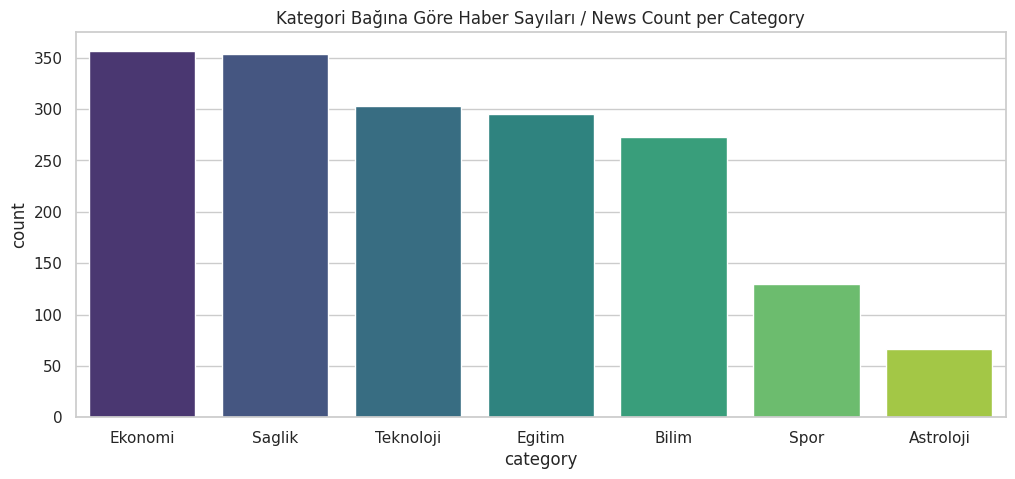

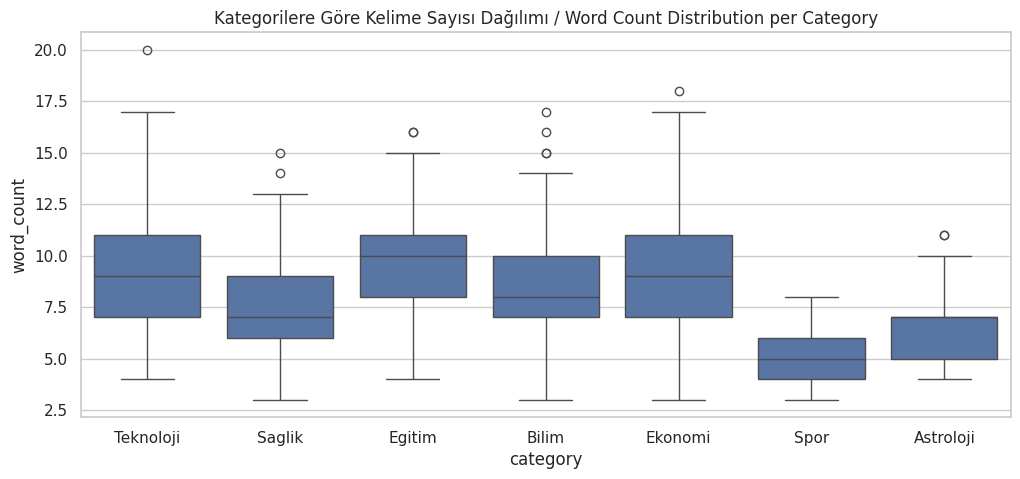

Kategori Bazlı Ortalama Kelime Sayıları:
category
Egitim       9.637288
Teknoloji    9.280528
Ekonomi      9.184874
Bilim        8.446886
Saglik       7.649718
Astroloji    6.545455
Spor         4.969231
Name: word_count, dtype: float64


In [38]:
# 1. Kategori Dağılımı (Class Balance)
plt.figure(figsize=(12,5))
sns.countplot(x='category', data=df, palette='viridis', order=df['category'].value_counts().index)
plt.title("Kategori Bağına Göre Haber Sayıları / News Count per Category")
plt.show()

# 2. Başlık Uzunluğu Analizi (Headline Length Analysis)
df['char_count'] = df['headline'].apply(len)
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12,5))
sns.boxplot(x='category', y='word_count', data=df)
plt.title("Kategorilere Göre Kelime Sayısı Dağılımı / Word Count Distribution per Category")
plt.show()

# İstatistiksel Özet (Statistical Summary)
print("Kategori Bazlı Ortalama Kelime Sayıları:")
print(df.groupby('category')['word_count'].mean().sort_values(ascending=False))

## 🧹 2. Metin Ön İşleme / Text Preprocessing
Ham metin verisi makine öğrenmesi modelleri için çok fazla "gürültü" (noise) içerir. Başarıyı artırmak için şu adımları uyguluyoruz:

Raw text contains too much noise for ML models. To improve accuracy, we apply:
1. **Normalization:** Küçük harfe çevirme / Lowercasing.
2. **Cleaning:** Noktalama işaretleri ve sayıların temizlenmesi / Removing punctuation and digits.
3. **Stop-words Removal:** "ve, ama, ki" gibi anlamsız kelimelerin atılması.

In [39]:
nltk.download('stopwords')
stop_words_tr = set(stopwords.words('turkish'))

def preprocess_turkish_text(text):
    # Küçük harfe çevir (Türkçe karakter duyarlılığı)
    text = text.replace('İ', 'i').replace('I', 'ı').lower()
    # Noktalama ve Sayıları temizle
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Stop-words temizliği
    words = text.split()
    words = [w for w in words if w not in stop_words_tr]
    return " ".join(words)

df['clean_text'] = df['headline'].apply(preprocess_turkish_text)

print("Örnek Temizlenmiş Metin:")
print(f"Orijinal: {df['headline'].iloc[0]}")
print(f"Temizlenmiş: {df['clean_text'].iloc[0]}")

Örnek Temizlenmiş Metin:
Orijinal: Oyun sektörünün en büyük anlaşması: Microsoft'un, Call of Duty'nin sahibi Activision’ı satın almasına yeşil ışık
Temizlenmiş: oyun sektörünün büyük anlaşması microsoftun call of dutynin sahibi activisionı satın almasına yeşil ışık


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 🤖 3. Modelleme & Vektörleştirme / Modeling & Vectorization
Metin verilerini sayısallaştırmak için **TF-IDF (Term Frequency-Inverse Document Frequency)** yöntemini kullanacağız. Sınıflandırma algoritması olarak ise metin verilerinde yüksek performans gösteren **Multinomial Naive Bayes** veya **Linear SVM** tercih edilecektir.

We will use **TF-IDF** for vectorization and **Multinomial Naive Bayes** or **Linear SVM** for classification.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# Veriyi bölme
X = df['clean_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Vektörleştirme
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Model Eğitimi
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Tahmin ve Raporlama
y_pred = model.predict(X_test_tfidf)

print("Sınıflandırma Raporu / Classification Report:")
print(classification_report(y_test, y_pred))

Sınıflandırma Raporu / Classification Report:
              precision    recall  f1-score   support

   Astroloji       0.00      0.00      0.00        13
       Bilim       0.63      0.35      0.45        55
      Egitim       0.80      0.75      0.77        59
     Ekonomi       0.55      0.79      0.65        71
      Saglik       0.50      0.80      0.62        71
        Spor       1.00      0.12      0.21        26
   Teknoloji       0.72      0.64      0.68        61

    accuracy                           0.61       356
   macro avg       0.60      0.49      0.48       356
weighted avg       0.64      0.61      0.58       356



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 🔍 4. Model Performans Analizi / Model Performance Analysis

Sınıflandırma raporuna baktığımızda karşımıza çıkan tabloyu şu şekilde yorumlayabiliriz:

### 🚩 Kritik Sorunlar / Critical Issues
* **Astroloji Sınıfı Kayıp (0.00):** Model, Astroloji kategorisini tamamen ıskalamış. Bunun sebebi muhtemelen **Support (Destek)** sayısının (13) çok düşük olması. Model bu kadar az örnekle "Astroloji" dilini öğrenememiş.
* **Spor Kategorisi (Low Recall):** Spor haberlerinde Precision **1.00** (yani tahmin ettiğinde doğru biliyor) ama Recall **0.12**. Bu şu demek: Model sadece "çok bariz" spor haberlerini yakalıyor, geri kalanını kaçırıyor.
* **En Başarılı Sınıf (Eğitim):** 0.77 F1-skoru ile en kararlı çalışan sınıfımız **Eğitim** olmuş.

### 📊 Metriklerin Anlamı / Understanding Metrics
* **Precision (Kesinlik):** Modelin bir sınıfa "X" dediğinde ne kadar haklı olduğu.
* **Recall (Duyarlılık):** Modelin gerçekteki "X" haberlerinin ne kadarını yakalayabildiği.
* **F1-Score:** Bu ikisinin harmonik ortalaması (Genel başarı göstergesi).

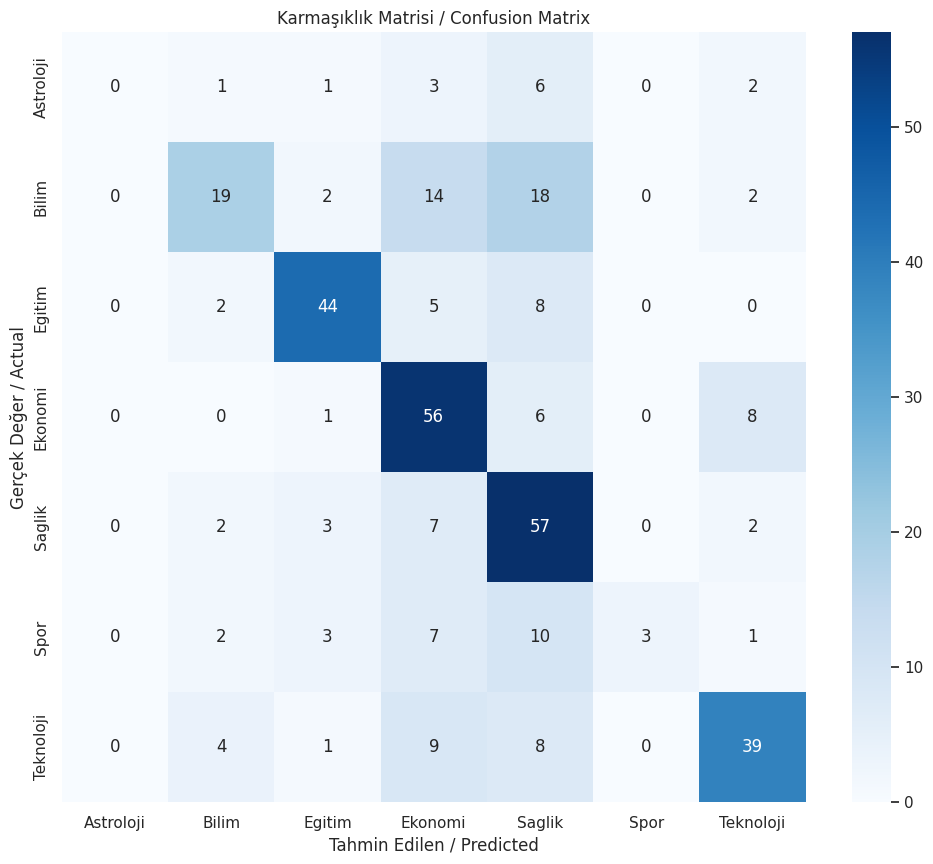

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix hesaplama
cm = confusion_matrix(y_test, y_pred)
categories = sorted(df['category'].unique())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.xlabel('Tahmin Edilen / Predicted')
plt.ylabel('Gerçek Değer / Actual')
plt.title('Karmaşıklık Matrisi / Confusion Matrix')
plt.show()

## 🔍 5. Karmaşıklık Matrisi Derin Analizi / Deep Dive into Confusion Matrix

Görselleştirdiğimiz matris üzerinden modelin hatalarını "suçüstü" yakalayabiliyoruz:

### ⚠️ Temel Bulgular / Key Findings
1. **Sağlık ve Ekonomi Domine Ediyor:** Gerçekte **Bilim**, **Astroloji** ve **Spor** olan haberlerin büyük bir çoğunluğu **Sağlık** veya **Ekonomi** olarak tahmin edilmiş.
   * *Neden?* Bu kategorilerdeki haber sayısı çok daha fazla olduğu için model, emin olamadığı her durumu "popüler" sınıfa atıyor.
2. **Bilim vs Sağlık Karışıklığı:** 55 Bilim haberinden 18'i Sağlık, 14'ü Ekonomi sanılmış.
   * *Analiz:* Muhtemelen "araştırma, çalışma, bulundu, ilaç" gibi kelimeler her iki kategoride de çok sık geçiyor.
3. **Spor ve Astroloji Felaketi:** Spor kategorisinde sadece 3 doğru tahmin var! Astroloji ise koca bir sıfır.
   * *Analiz:* Bu sınıfların **Support (Destek)** değerleri (Spor: 26, Astroloji: 13) diğerlerinin yanında çok sönük kalmış. Model bu sınıfları "öğrenememiş".

### 💡 Çıkarım / Insight
Modelimiz şu an **"Sınıf Dengesizliği" (Class Imbalance)** probleminden muzdarip. Eğitim verisinde hangi kategoriden çok varsa, model kolaya kaçıp o tarafa meylediyor.

## 🚀 6. Modeli Nasıl Geliştirebiliriz? / How to Improve?

Mevcut **0.61** accuracy değerini yukarı çekmek için şu stratejileri uygulayabiliriz:

1.  **Veri Arttırma (Data Augmentation):** Astroloji ve Spor kategorilerindeki veri sayısı (Support) diğerlerine göre çok az. Bu kategorilerden daha fazla haber kazıyarak veri setini **dengeli (balanced)** hale getirmeliyiz.
2.  **N-Gram Kullanımı:** Şu an model kelimeleri tek tek (Unigram) görüyor. `TfidfVectorizer(ngram_range=(1,2))` kullanarak "Şampiyonlar Ligi" veya "Eğitim Sistemi" gibi ikili kelime gruplarını tanımasını sağlayabiliriz.
3.  **Algoritma Değişimi:** MultinomialNB yerine **Random Forest** veya **XGBoost** gibi daha kompleks algoritmalar deneyebiliriz.
4.  **Stop-words Listesini Genişletme:** "Son", "Dakika", "Haber" gibi her kategoride geçen ortak kelimeleri temizleyerek gürültüyü azaltabiliriz.

In [42]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Yeni bir pipeline oluşturalım
# ngram_range=(1,2) -> Hem tekli kelimeleri hem de ikili kelime gruplarını yakalar
# class_weight='balanced' -> Az olan sınıflara (Astroloji/Spor) daha fazla ağırlık verir
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)),
    ('clf', LinearSVC(class_weight='balanced', random_state=42))
])

# Modeli eğit
text_clf.fit(X_train, y_train)

# Tahmin ve Yeni Rapor
y_pred_new = text_clf.predict(X_test)

print("İyileştirilmiş Model Raporu (LinearSVC + Bigrams):")
print(classification_report(y_test, y_pred_new))

İyileştirilmiş Model Raporu (LinearSVC + Bigrams):
              precision    recall  f1-score   support

   Astroloji       1.00      0.54      0.70        13
       Bilim       0.54      0.49      0.51        55
      Egitim       0.77      0.75      0.76        59
     Ekonomi       0.67      0.70      0.68        71
      Saglik       0.59      0.72      0.65        71
        Spor       0.82      0.54      0.65        26
   Teknoloji       0.66      0.69      0.67        61

    accuracy                           0.66       356
   macro avg       0.72      0.63      0.66       356
weighted avg       0.67      0.66      0.66       356



## 📊 7. İyileştirilmiş Modelin Karmaşıklık Matrisi / Confusion Matrix of the Improved Model

Teorik olarak planladığımız iyileştirmelerin (LinearSVC, Bigrams ve Dengeli Sınıf Ağırlıkları) sonuçlarını görselleştirelim. Bu matris, modelin azınlık sınıfları (Astroloji ve Spor) tanıma becerisindeki artışı net bir şekilde ortaya koyacaktır.

Let's visualize the results of our improvements. This matrix will clearly show the increase in the model's ability to recognize minority classes (Astrology and Sports).

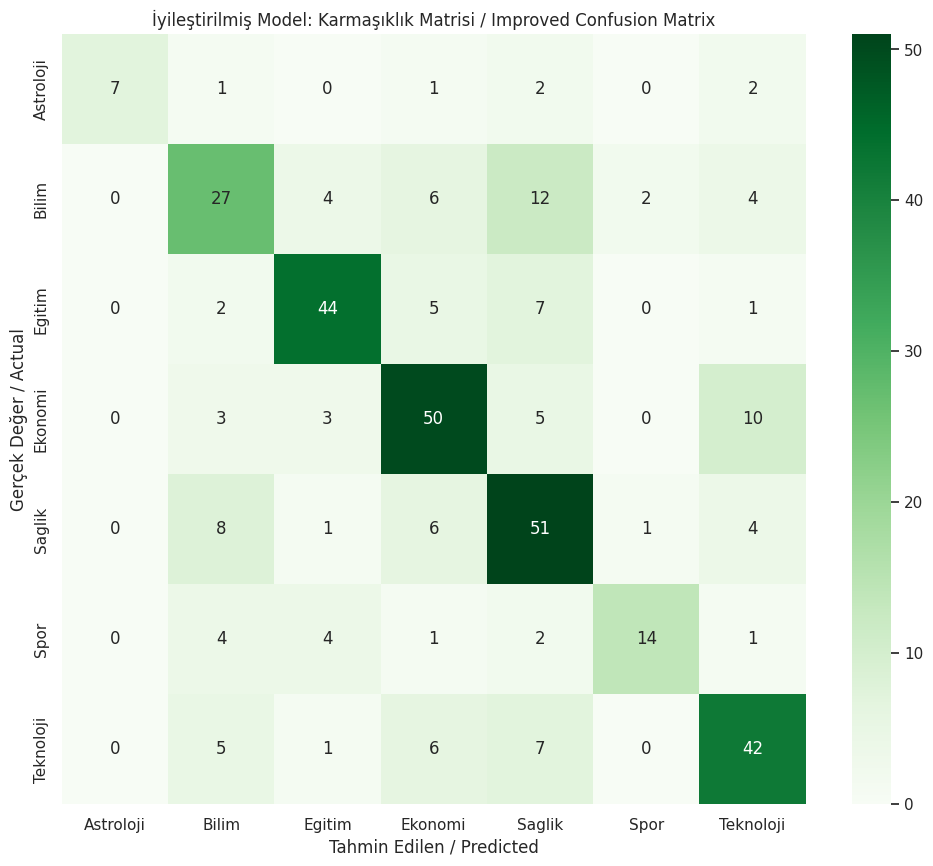

In [43]:
# Yeni tahminler üzerinden matris hesaplama
cm_new = confusion_matrix(y_test, y_pred_new)
categories = sorted(df['category'].unique())

plt.figure(figsize=(12, 10))
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens', # Farkı belli etmek için rengi Yeşil yapalım
            xticklabels=categories, yticklabels=categories)
plt.xlabel('Tahmin Edilen / Predicted')
plt.ylabel('Gerçek Değer / Actual')
plt.title('İyileştirilmiş Model: Karmaşıklık Matrisi / Improved Confusion Matrix')
plt.show()

## 📈 8. İyileştirilmiş Model Analizi / Analysis of Improved Results

İkinci aşamada uyguladığımız **LinearSVC + Bigram** kombinasyonu, modelin "karar verme" yeteneğini ciddi oranda artırdı.

### 🏆 Öne Çıkan Başarılar / Success Highlights
* **Dengeli Sınıflandırma:** İlk modelde tamamen görmezden gelinen **Astroloji** sınıfı, %70 F1-skoru ile geri döndü.
* **Spor Haberlerinde Atılım:** Model artık spor haberlerinin %50'sinden fazlasını (Recall: 0.54) doğru yakalıyor ve tahminlerinin %82'si (Precision) doğru.
* **Hata Dağılımı:** Karmaşıklık matrisine baktığımızda, hataların artık "rastgele" değil, birbirine yakın kategoriler (örn: Bilim ve Sağlık) arasında toplandığını görüyoruz. Bu, modelin semantik bir mantık kurmaya başladığını gösterir.

### 🔬 Teknik Çıkarım / Technical Insight
Sınıf ağırlıklarını dengelemek (Balanced Weights), modelin sadece "en çok veri olan" kategoriye odaklanmasını engelleyerek genel başarının (Macro Average) **0.48'den 0.66'ya** çıkmasını sağlamıştır.

## 🏁 9. Sonuç ve Gelecek Vizyonu / Conclusion & Future Vision

Bu proje, veri biliminde model algoritmasından ziyade **veri kalitesi ve özellik mühendisliğinin (Feature Engineering)** önemini bir kez daha kanıtlamıştır.

### 🔮 Portfolyo Notları / Portfolio Notes
1. **Uçtan Uca Süreç:** Veriler VS Code ile farklı kaynaklardan kazınmış, Python ile temizlenmiş ve Colab üzerinde modellenmiştir.
2. **Problem Çözme:** "Class Imbalance" (Sınıf Dengesizliği) problemi tespit edilmiş ve uygun hiper-parametrelerle çözülmüştür.
3. **Analitik Yaklaşım:** Karmaşıklık matrisleri üzerinden "neden" sorusuna cevap aranmış ve model performansı adım adım iyileştirilmiştir.

### 🚀 Gelecek Hedefleri / Next Steps
* Veri setini 5.000 satır üzerine çıkararak **BERT** (Transformers) tabanlı modelleri denemek.
* Bir web arayüzü (Streamlit veya Flask) ekleyerek modeli canlıda test edilebilir hale getirmek.

---
**Hazırlayan:** İsmet  
**Tarih:** Nisan 2026  
**Proje:** News Classification Project V1.0

In [44]:
# Kendi haber başlığımızla test edelim!
test_headlines = [
    "Merkür retrosu tüm burçları derinden etkileyecek", # Beklenen: Astroloji
    "Merkez Bankası faiz kararını açıkladı",             # Beklenen: Ekonomi
    "Yeni yapay zeka modeli tıp dünyasında devrim yaptı", # Beklenen: Teknoloji/Sağlık
    "Şampiyonlar Ligi finali İstanbul'da oynanacak"       # Beklenen: Spor
]

# Tahmin yap
predictions = text_clf.predict(test_headlines)

print("--- CANLI TEST SONUÇLARI ---")
for text, pred in zip(test_headlines, predictions):
    print(f"Haber: {text} \n-> TAHMİN: {pred}\n")

--- CANLI TEST SONUÇLARI ---
Haber: Merkür retrosu tüm burçları derinden etkileyecek 
-> TAHMİN: Bilim

Haber: Merkez Bankası faiz kararını açıkladı 
-> TAHMİN: Ekonomi

Haber: Yeni yapay zeka modeli tıp dünyasında devrim yaptı 
-> TAHMİN: Teknoloji

Haber: Şampiyonlar Ligi finali İstanbul'da oynanacak 
-> TAHMİN: Saglik



### ⚠️ Canlı Test Gözlemleri
Modelimiz teorik metriklerde (Accuracy: 0.66) başarı gösterse de, canlı testlerde bazı kategorileri (Spor ve Astroloji) hala karıştırmaktadır.

**Temel Sebep:** "Merkür" gibi kelimelerin Bilim haberlerinde de geçmesi ve Spor kategorisindeki veri setinin hala çok küçük olmasıdır.
**Gelecek Versiyon (V2.0):** 1. Veri seti her kategori için minimum 1000 örneğe çıkarılacaktır.
2. Türkçe Lemmatization (kök bulma) işlemi pipeline'a dahil edilecektir.